# Backtest Overfitting: the Deflated Sharpe Ratio and PBO

**Question:** If you try 280 moving-average rules on the S&P 500 and report the best one, how much of its Sharpe ratio is skill and how much is selection?

A backtest is a sample statistic. Picking the best of many backtests is a *maximum* of sample statistics, and the maximum of noise is not zero. This notebook measures that bias with two tools from Bailey & López de Prado:

- **Deflated Sharpe Ratio (DSR):** the probability that the true Sharpe ratio is positive *after* accounting for the number of trials, the track-record length and non-normal returns.
- **Probability of Backtest Overfitting (PBO):** estimated with Combinatorially Symmetric Cross-Validation (CSCV). How often does the in-sample winner fall below the median out-of-sample?

It applies them to a grid of MA-crossover rules, the technical-analysis family studied in de Souza et al. (2018) and covered in WQU MScFE 560, Module 6 ("More than one way to pick a stock"). References are in `reference.md`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3})
RNG = np.random.default_rng(7)
EULER_GAMMA = 0.5772156649
ANN = 252

## 1. The best of N coin flips

Simulate $N$ strategies that have **zero** true edge: daily returns are i.i.d. $\mathcal{N}(0, 1\%)$ over $T = 1250$ days (5 years). Report the highest annualized Sharpe ratio among them. For large $N$, extreme value theory gives the expected maximum:

$$ \mathbb{E}\big[\max_n \widehat{SR}_n\big] \approx \sqrt{V[\widehat{SR}_n]}\,\Big((1-\gamma)\,Z^{-1}\big[1-\tfrac1N\big] + \gamma\, Z^{-1}\big[1-\tfrac{1}{Ne}\big]\Big), $$

where $\gamma \approx 0.5772$ is the Euler-Mascheroni constant and $Z^{-1}$ is the standard normal quantile. Under the null, $V[\widehat{SR}_n] \approx 1/T$ per period.

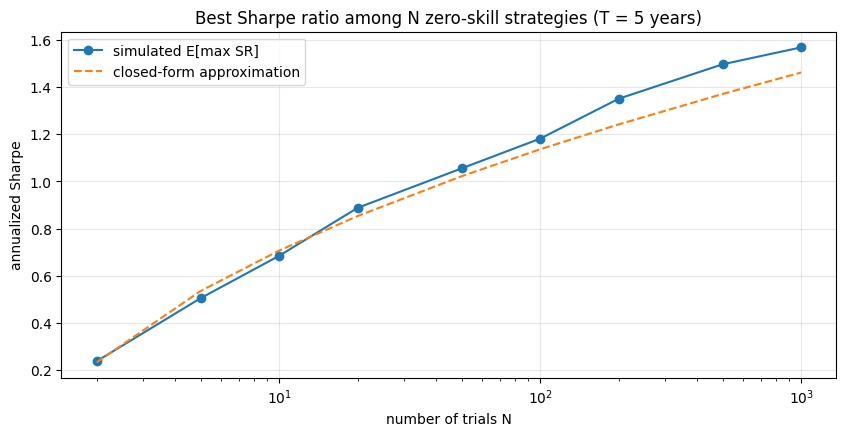

N,2,5,10,20,50,100,200,500,1000
simulated,0.24,0.51,0.68,0.89,1.06,1.18,1.35,1.50,1.57
formula,0.23,0.54,0.71,0.85,1.02,1.14,1.24,1.37,1.46


In [2]:
def expected_max_sr(var_sr, n_trials):
    # Expected maximum of n_trials Sharpe ratios with zero mean and variance var_sr (same units as var_sr)
    n = np.asarray(n_trials, dtype=float)
    return np.sqrt(var_sr) * ((1 - EULER_GAMMA) * stats.norm.ppf(1 - 1 / n)
                              + EULER_GAMMA * stats.norm.ppf(1 - 1 / (n * np.e)))


T = 1250
Ns = np.array([2, 5, 10, 20, 50, 100, 200, 500, 1000])
noise = RNG.normal(0, 0.01, size=(T, Ns.max()))
sr_noise = noise.mean(0) / noise.std(0, ddof=1) * np.sqrt(ANN)

sim_max = [np.mean([RNG.choice(sr_noise, n, replace=False).max() for _ in range(300)]) for n in Ns]
theory = expected_max_sr(1 / T, Ns) * np.sqrt(ANN)

fig, ax = plt.subplots()
ax.plot(Ns, sim_max, "o-", label="simulated E[max SR]")
ax.plot(Ns, theory, "--", label="closed-form approximation")
ax.set_xscale("log"); ax.set_xlabel("number of trials N"); ax.set_ylabel("annualized Sharpe")
ax.set_title("Best Sharpe ratio among N zero-skill strategies (T = 5 years)")
ax.legend(); plt.show()
pd.DataFrame({"N": Ns, "simulated": np.round(sim_max, 2), "formula": np.round(theory, 2)}).set_index("N").T

With 5 years of data, trying about 100 random strategies is enough to find one with an annualized Sharpe above 1. That is the level many people treat as "a real strategy".

## 2. PSR, DSR and minimum track record length

**Probabilistic Sharpe Ratio.** Given the observed per-period $\widehat{SR}$ over $T$ observations with skewness $\gamma_3$ and (non-excess) kurtosis $\gamma_4$, the probability that the true SR exceeds a benchmark $SR^*$ is

$$ \mathrm{PSR}(SR^*) = Z\!\left[\frac{(\widehat{SR}-SR^*)\sqrt{T-1}}{\sqrt{1-\gamma_3\widehat{SR}+\frac{\gamma_4-1}{4}\widehat{SR}^2}}\right]. $$

Negative skew and fat tails widen the denominator, so they lower the confidence.

**Deflated Sharpe Ratio.** DSR is PSR with the benchmark set to the expected maximum SR under the null, $SR^* = SR_0 = \mathbb{E}[\max \widehat{SR}_n]$, using the *actual* variance of Sharpe ratios across the $N$ trials.

**Minimum track record length.** The $T$ needed for $\mathrm{PSR}(SR^*) \ge 1-\alpha$:
$\;\mathrm{MinTRL} = 1 + \big(1-\gamma_3\widehat{SR}+\frac{\gamma_4-1}{4}\widehat{SR}^2\big)\big(\frac{z_{1-\alpha}}{\widehat{SR}-SR^*}\big)^2$.

All Sharpe ratios here are **per period** (not annualized) unless labelled otherwise.

In [3]:
def sharpe(r):
    # works on ndarray, Series or DataFrame (column-wise); keeps pandas labels
    return r.mean(0) / r.std(0, ddof=1)


def psr(sr, T, skew, kurt, sr_star=0.0):
    return stats.norm.cdf((sr - sr_star) * np.sqrt(T - 1) / np.sqrt(1 - skew * sr + (kurt - 1) / 4 * sr ** 2))


def dsr(sr, T, skew, kurt, var_sr_trials, n_trials):
    sr0 = expected_max_sr(var_sr_trials, n_trials)
    return psr(sr, T, skew, kurt, sr_star=sr0), sr0


def min_trl(sr, skew, kurt, sr_star=0.0, alpha=0.05):
    return 1 + (1 - skew * sr + (kurt - 1) / 4 * sr ** 2) * (stats.norm.ppf(1 - alpha) / (sr - sr_star)) ** 2


# Paper's numerical example: annual SR 2.5 on daily data, N = 100, V[SR_n] = 1/2 (annual), T = 1250, skew -3, kurt 10
sr_d = 2.5 / np.sqrt(250)
val, sr0 = dsr(sr_d, T=1250, skew=-3, kurt=10, var_sr_trials=0.5 / 250, n_trials=100)
print(f"SR0 (annualized) = {sr0 * np.sqrt(250):.3f}   DSR = {val:.4f}   (paper: ~0.90)")
assert abs(val - 0.90) < 0.01

SR0 (annualized) = 1.789   DSR = 0.9004   (paper: ~0.90)


So an annualized Sharpe of 2.5 found after 100 trials, with fat left tails, passes at only 90% confidence, below the usual 95%.

## 3. Data: SPY daily

We use SPY from 2000 onward and keep the **last three years as an untouched holdout**. All strategy selection happens before the holdout. If `yfinance` is unavailable, a GBM path with fat-tailed shocks stands in.

In [4]:
START, HOLDOUT_START = "2000-01-01", "2023-01-01"


def load_spy():
    try:
        import yfinance as yf
        px = yf.download("SPY", start=START, progress=False, auto_adjust=True)["Close"]
        px = px.squeeze().dropna()
        if len(px) < 2000:
            raise ValueError("too little data")
        return px, "yfinance"
    except Exception as exc:
        print(f"yfinance unavailable ({exc}); using synthetic data")
        n = 6500
        r = 0.0003 + 0.012 * RNG.standard_t(4, n) / np.sqrt(2)
        return pd.Series(100 * np.exp(np.cumsum(r)), index=pd.bdate_range(START, periods=n)), "synthetic"


px, SOURCE = load_spy()
ret = px.pct_change().dropna()
print(f"source={SOURCE}  {ret.index[0].date()} → {ret.index[-1].date()}  obs={len(ret)}")

source=yfinance  2000-01-04 → 2026-09-28  obs=6723


## 4. A grid of moving-average rules

Each rule compares a fast and a slow moving average (SMA or EMA) of price and goes **long** when fast > slow. When fast < slow it is either **flat** or **short**. Signals use yesterday's close (no look-ahead), and every change in position pays 2 bps. Each rule is one "trial".

trials N = 280   in-sample T = 5485   holdout T = 937


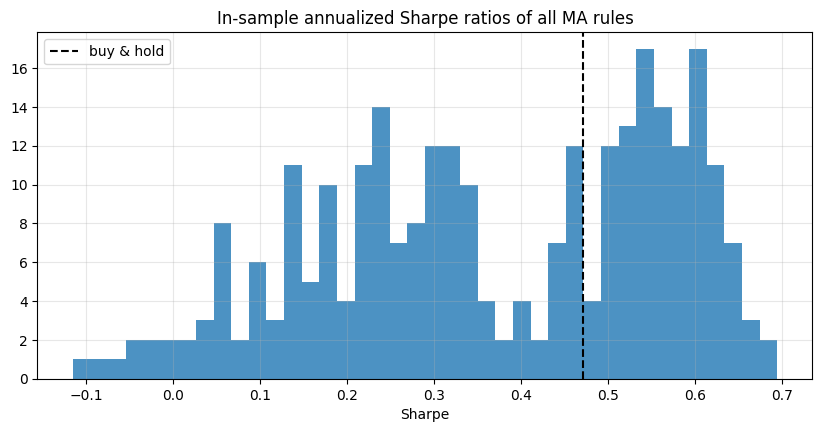

SMA_10_200_LF     0.694
SMA_10_75_LF      0.683
SMA_40_250_LF     0.662
SMA_100_300_LF    0.655
SMA_5_250_LF      0.655
EMA_10_300_LF     0.650
SMA_30_200_LF     0.648
SMA_10_250_LF     0.646
SMA_5_300_LF      0.644
SMA_50_250_LF     0.639
dtype: float64

In [5]:
FAST = [5, 10, 15, 20, 30, 40, 50, 60, 80, 100]
SLOW = [20, 30, 50, 75, 100, 150, 200, 250, 300]
COST = 2e-4


def ma(p, n, kind):
    return p.rolling(n).mean() if kind == "SMA" else p.ewm(span=n, adjust=False).mean()


def run_grid(px, ret):
    out = {}
    for kind in ("SMA", "EMA"):
        cache = {n: ma(px, n, kind) for n in set(FAST) | set(SLOW)}
        for f in FAST:
            for s in SLOW:
                if f >= s:
                    continue
                up = (cache[f] > cache[s]).astype(float)
                for mode, down in (("LF", 0.0), ("LS", -1.0)):
                    pos = up.where(up == 1, down).shift(1).reindex(ret.index)
                    pos.iloc[:s] = np.nan  # warm-up
                    pnl = pos * ret - COST * pos.diff().abs()
                    out[f"{kind}_{f}_{s}_{mode}"] = pnl
    return pd.DataFrame(out).dropna()


all_pnl = run_grid(px, ret)
is_pnl = all_pnl[all_pnl.index < HOLDOUT_START]
ho_pnl = all_pnl[all_pnl.index >= HOLDOUT_START]
print(f"trials N = {all_pnl.shape[1]}   in-sample T = {len(is_pnl)}   holdout T = {len(ho_pnl)}")

sr_is = sharpe(is_pnl) * np.sqrt(ANN)
fig, ax = plt.subplots()
ax.hist(sr_is, bins=40, alpha=0.8)
ax.axvline(sharpe(ret.loc[is_pnl.index]) * np.sqrt(ANN), color="k", ls="--", label="buy & hold")
ax.set_title("In-sample annualized Sharpe ratios of all MA rules"); ax.set_xlabel("Sharpe"); ax.legend()
plt.show()
sr_is.sort_values(ascending=False).head(10).round(3)

## 5. Deflating the winner

Rules on the same grid are highly correlated, so 200 rules are not 200 *independent* trials. We estimate the effective number of independent trials from the eigenvalues $\lambda_i$ of the trials' correlation matrix (participation ratio):

$$ N_{\text{eff}} = \frac{(\sum_i \lambda_i)^2}{\sum_i \lambda_i^2}. $$

We report DSR using both $N_{\text{eff}}$ (a realistic figure) and the raw $N$ (a conservative bound).

In [6]:
best = sr_is.idxmax()
r_best = is_pnl[best]
sr_b = sharpe(r_best)
skew_b, kurt_b = stats.skew(r_best), stats.kurtosis(r_best, fisher=False)
T_is = len(r_best)

eig = np.linalg.eigvalsh(is_pnl.corr().values)
n_eff = eig.sum() ** 2 / (eig ** 2).sum()
var_sr = sharpe(is_pnl).var(ddof=1)

rows = {"PSR (SR* = 0)": (psr(sr_b, T_is, skew_b, kurt_b), 0.0)}
for label, n in (("DSR (N_eff)", n_eff), ("DSR (raw N)", is_pnl.shape[1])):
    rows[label] = dsr(sr_b, T_is, skew_b, kurt_b, var_sr, n)

print(f"best rule: {best}   annual SR = {sr_b * np.sqrt(ANN):.3f}   skew = {skew_b:.2f}   kurtosis = {kurt_b:.1f}")
print(f"N raw = {is_pnl.shape[1]}   N_eff ≈ {n_eff:.1f}   std of trial SRs (annual) = {np.sqrt(var_sr * ANN):.3f}")
pd.DataFrame({"probability": {k: v[0] for k, v in rows.items()},
              "hurdle SR0 (annual)": {k: v[1] * np.sqrt(ANN) for k, v in rows.items()}}).round(3)

best rule: SMA_10_200_LF   annual SR = 0.694   skew = -0.89   kurtosis = 11.1
N raw = 280   N_eff ≈ 3.0   std of trial SRs (annual) = 0.196


,probability,hurdle SR0 (annual)
PSR (SR* = 0),0.999,0.000
DSR (N_eff),0.992,0.168
DSR (raw N),0.727,0.562


In [7]:
trl = min_trl(sr_b, skew_b, kurt_b, sr_star=rows["DSR (N_eff)"][1])
print(f"Minimum track record to beat the deflated hurdle at 95%: "
      f"{trl:,.0f} days ≈ {trl / ANN:.1f} years (have {T_is / ANN:.1f})" if np.isfinite(trl) and sr_b > rows['DSR (N_eff)'][1]
      else "Best rule's SR is below the deflated hurdle: no track record length would be enough.")

Minimum track record to beat the deflated hurdle at 95%: 2,569 days ≈ 10.2 years (have 21.8)


## 6. Probability of Backtest Overfitting (CSCV)

DSR asks whether the winner's SR is significant. PBO asks a more practical question: **does the selection procedure pick rules that do well out of sample?**

CSCV (Bailey, Borwein, López de Prado & Zhu):
1. Split the $T \times N$ in-sample returns matrix into $S$ equal time blocks ($S=16$).
2. For every way of choosing $S/2$ blocks as the training set ($\binom{16}{8} = 12{,}870$ splits), the remaining blocks form the test set.
3. Pick the rule with the best training Sharpe and find its relative rank $\bar\omega \in (0,1)$ among all rules on the test set.
4. Record the logit $\lambda = \ln\frac{\bar\omega}{1-\bar\omega}$.

$\mathrm{PBO} = \Pr[\lambda \le 0]$, the probability that the in-sample winner is below the out-of-sample median. For a set of pure-noise strategies PBO ≈ 0.5.

Because training and test sets are unions of blocks, we precompute per-block sums so each split's Sharpe ratios are fully vectorized.

In [8]:
def cscv(returns, S=16):
    X = np.asarray(returns)
    T, N = X.shape
    X = X[: T - T % S]
    blocks = X.reshape(S, -1, N)
    n_b = blocks.shape[1]
    s1, s2 = blocks.sum(1), (blocks ** 2).sum(1)  # (S, N)

    def sr_of(idx):
        n = n_b * len(idx)
        m = s1[idx].sum(0) / n
        v = (s2[idx].sum(0) - n * m ** 2) / (n - 1)
        return m / np.sqrt(v)

    logits, is_best, oos_best = [], [], []
    all_idx = np.arange(S)
    for train in combinations(all_idx, S // 2):
        train = np.array(train)
        test = np.setdiff1d(all_idx, train)
        sr_tr, sr_te = sr_of(train), sr_of(test)
        k = np.argmax(sr_tr)
        rank = stats.rankdata(sr_te)[k] / (N + 1)
        logits.append(np.log(rank / (1 - rank)))
        is_best.append(sr_tr[k]); oos_best.append(sr_te[k])
    logits = np.array(logits)
    return {"pbo": np.mean(logits <= 0), "logits": logits,
            "is_sr": np.array(is_best) * np.sqrt(ANN), "oos_sr": np.array(oos_best) * np.sqrt(ANN)}


res_ma = cscv(is_pnl.values)
res_noise = cscv(RNG.normal(0, 0.01, size=is_pnl.shape))  # control: zero-skill strategies of the same shape
print(f"PBO (MA grid)     = {res_ma['pbo']:.3f}")
print(f"PBO (pure noise)  = {res_noise['pbo']:.3f}   ← sanity check, should be ≈ 0.5")
print(f"P(OOS SR of selected rule < 0) = {np.mean(res_ma['oos_sr'] < 0):.3f}")

PBO (MA grid)     = 0.211
PBO (pure noise)  = 0.569   ← sanity check, should be ≈ 0.5
P(OOS SR of selected rule < 0) = 0.021


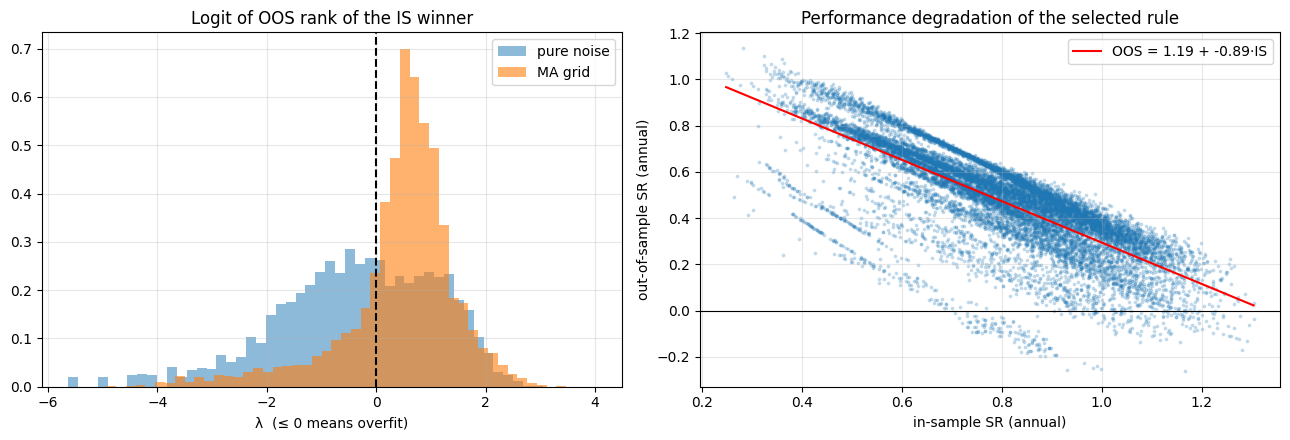

mean IS SR of winner = 0.80   mean OOS SR of winner = 0.47


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(res_noise["logits"], bins=50, alpha=0.5, density=True, label="pure noise")
axes[0].hist(res_ma["logits"], bins=50, alpha=0.6, density=True, label="MA grid")
axes[0].axvline(0, color="k", ls="--")
axes[0].set_title("Logit of OOS rank of the IS winner"); axes[0].set_xlabel("λ  (≤ 0 means overfit)"); axes[0].legend()

b, a = np.polyfit(res_ma["is_sr"], res_ma["oos_sr"], 1)
axes[1].scatter(res_ma["is_sr"], res_ma["oos_sr"], s=3, alpha=0.2)
xs = np.linspace(res_ma["is_sr"].min(), res_ma["is_sr"].max(), 50)
axes[1].plot(xs, a + b * xs, "r-", label=f"OOS = {a:.2f} + {b:.2f}·IS")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("Performance degradation of the selected rule")
axes[1].set_xlabel("in-sample SR (annual)"); axes[1].set_ylabel("out-of-sample SR (annual)"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"mean IS SR of winner = {res_ma['is_sr'].mean():.2f}   mean OOS SR of winner = {res_ma['oos_sr'].mean():.2f}")

## 7. Final holdout

The last check is the simplest: take the rule chosen on the full in-sample period and run it on the 2023+ holdout, which it has never seen.

                           in-sample SR  holdout SR holdout rank of best rule
best rule (SMA_10_200_LF)         0.694       1.285        beats 85% of rules
buy & hold SPY                    0.471       1.405                          
median rule                       0.360       1.054                          


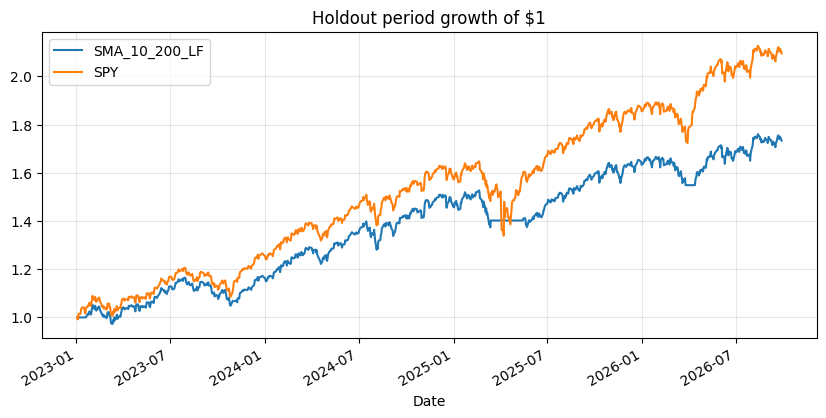

In [10]:
spy_ho = ret.loc[ho_pnl.index]
ho = pd.DataFrame({
    "in-sample SR": [sr_is[best], sharpe(ret.loc[is_pnl.index]) * np.sqrt(ANN), sr_is.median()],
    "holdout SR": [sharpe(ho_pnl[best]) * np.sqrt(ANN), sharpe(spy_ho) * np.sqrt(ANN),
                   np.median(sharpe(ho_pnl) * np.sqrt(ANN))],
}, index=[f"best rule ({best})", "buy & hold SPY", "median rule"])
ho["holdout rank of best rule"] = ""
ho.iloc[0, 2] = f"beats {(sharpe(ho_pnl) < sharpe(ho_pnl[best])).mean():.0%} of rules"
print(ho.round(3).to_string())

(1 + pd.DataFrame({best: ho_pnl[best], "SPY": spy_ho})).cumprod().plot(title="Holdout period growth of $1")
plt.show()

## 8. Takeaways

The numbers below come from the run with yfinance data (SPY 2000 → Sep 2026). They will shift a little as new data arrives.

- **Selection bias is large and predictable.** With 5 years of data, the best of 100 zero-skill strategies has an expected annualized Sharpe of about 1.2. The closed-form $\mathbb{E}[\max SR]$ tracks the simulation closely.
- **The winner looks significant until you count trials.** The best rule, SMA(10, 200) long/flat, had an in-sample Sharpe of 0.69 against 0.47 for buy & hold, and PSR ≈ 0.999. Its DSR depends heavily on *how many trials you admit to*: 0.99 using the effective number of trials (N_eff ≈ 3), but only 0.73 using the raw 280. The deflation is only as honest as the trial log, so record every configuration you test.
- **The grid is really about three bets.** Participation-ratio N_eff ≈ 3 because nearly every long/flat rule does the same thing: it steps out of the market during the 2001-02 and 2008 drawdowns. The eigenvalue measure is dominated by that common market factor, so treat it as a *lower* bound on the true number of trials.
- **PBO is modest, but degradation is real.** CSCV gives PBO ≈ 0.21 against ≈ 0.57 for the pure-noise control, so picking the best in-sample rule usually lands above the median out-of-sample. Still, the winner's Sharpe falls from 0.80 in-sample to 0.47 out-of-sample on average, roughly a 40% haircut.
- **The holdout gives a sober verdict.** From 2023 on, the chosen rule beat 85% of the other rules (SR 1.29) but lost to plain buy & hold (SR 1.41). In a steady bull market a trend filter costs return. This matches the mixed evidence on MA rules in de Souza et al. (2018).

**Checklist for any strategy in this portfolio:** log every trial; report PSR and DSR, not raw SR; run CSCV on the full grid; keep a holdout you never touch until the end.

**Extensions:** a better N_eff (clustering trials as in López de Prado's "detection of false investment strategies"), the Harvey-Liu haircut Sharpe, and applying the same test to the strategies in `TRADER-2/strategies`.